<a href="https://colab.research.google.com/github/smitp2705/Practical_test_SUP/blob/main/HousePrice_Prediction_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# House Price Prediction — Regression with Supervised Learning
**Ames Housing Dataset | PropTech Startup Use-Case**

This notebook builds a complete end-to-end supervised learning pipeline to predict `SalePrice`
for residential homes, following the exam brief (Set A).


## Step 1: Problem Framing & Theory Notes

### 1. What is Regression? How is it different from Classification?

- **Regression** predicts a **continuous numeric value** (e.g., a price, a temperature, a score).
- **Classification** predicts a **discrete category/label** (e.g., spam vs not-spam).
- The error metrics differ too: regression uses RMSE/MAE/R², classification uses accuracy/precision/recall.
- **Indian examples:**
  - Predicting the **monthly EMI amount** a customer at HDFC Bank should pay based on loan amount, tenure, and interest rate — a regression problem (continuous EMI value).
  - Predicting **crop yield (tonnes/hectare)** for a farm in Maharashtra based on rainfall, soil quality, and fertilizer usage — a regression problem (continuous yield value).


### 2. Simple Linear Regression vs Multiple Linear Regression vs Regularised Regression

- **Simple Linear Regression:** one input feature predicts the target (e.g., `GrLivArea → SalePrice`).
- **Multiple Linear Regression:** many input features predict the target simultaneously (e.g., `GrLivArea, OverallQual, YearBuilt, ... → SalePrice`).
- **Regularised Regression (Ridge/Lasso):** Multiple Linear Regression with an added **penalty term** on the coefficients to control overfitting.
  - **Ridge (L2):** shrinks coefficients towards zero but rarely to exactly zero.
  - **Lasso (L1):** can shrink some coefficients all the way to **zero**, performing automatic feature selection.


### 3. Overfitting and Underfitting

- **Overfitting:** the model learns the training data (including noise) too well and performs poorly on unseen/test data — low training error, high test error.
- **Underfitting:** the model is too simple to capture the underlying pattern — high error on both training and test data.
- **How regularisation helps:**
  - L1/L2 penalties discourage large coefficient values, which keeps the model simpler and less sensitive to noise in the training data.
  - This trades a small increase in training error for a larger reduction in test error (better generalisation), and Lasso's coefficient-to-zero property also removes irrelevant features.


### 4. RMSE, MAE, and R²

- **RMSE (Root Mean Squared Error):** square root of the average of squared errors. Penalises **large errors more heavily** because errors are squared before averaging.
- **MAE (Mean Absolute Error):** average of the absolute errors. Treats all error sizes **proportionally** (linearly).
- **R² (Coefficient of Determination):** proportion of variance in the target explained by the model (1.0 = perfect fit, 0 = no better than predicting the mean).
- **When to prefer RMSE over MAE:** when large errors are especially costly or undesirable (e.g., mispricing a house by ₹50 lakh is much worse than being off by ₹5 lakh ten times) — RMSE's squaring makes it more sensitive to such large deviations, which is useful when we specifically want to penalise big misses.


### 5. What is Cross-Validation (k-Fold)?

- **k-Fold Cross-Validation** splits the training data into *k* equal parts (folds). The model is trained on *k-1* folds and validated on the remaining fold, and this is repeated *k* times so every fold is used once for validation.
- The final performance estimate is the **average across all k runs**.
- **Why preferred over a single train-test split:**
  - A single split's performance estimate can vary a lot depending on which rows happen to land in the test set (high variance).
  - k-Fold CV uses the entire dataset for both training and validation across folds, giving a **more stable and reliable estimate** of how the model will perform on unseen data.


## Step 2: Dataset Loading & Exploratory Data Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', 100)
plt.rcParams['figure.figsize'] = (6, 4)




In [ ]:
df = pd.read_csv("/content/train.csv")
print("Shape:", df.shape)

Shape: (1460, 81)


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
df.describe()


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### 2.1 Load & Understand the Dataset

In [ ]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
missing = df.isnull().sum()
missing = missing[missing > 0]

print(f"Numerical columns: {len(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")
print(f"Columns with missing values: {len(missing)}")


Numerical columns: 38
Categorical columns: 43
Columns with missing values: 19


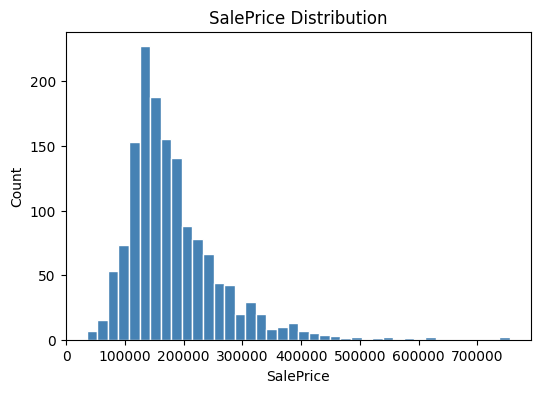

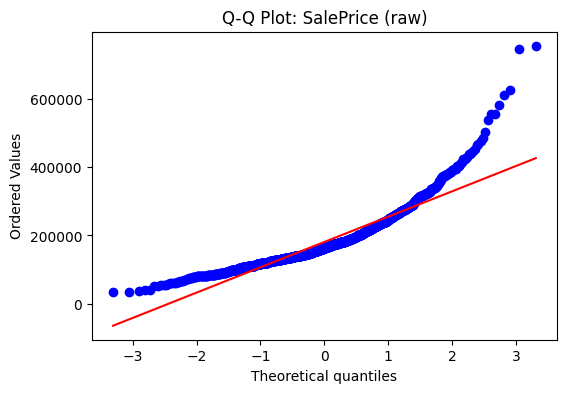

Skewness of SalePrice: 1.883


In [ ]:
# Distribution of SalePrice
plt.figure()
plt.hist(df['SalePrice'], bins=40, color='steelblue', edgecolor='white')
plt.title("SalePrice Distribution")
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.show()

plt.figure()
stats.probplot(df['SalePrice'], plot=plt)
plt.title("Q-Q Plot: SalePrice (raw)")
plt.show()

print("Skewness of SalePrice:", df['SalePrice'].skew().round(3))


`SalePrice` is **right-skewed** (skew > 1) and the Q-Q plot shows it deviates from the diagonal at the upper tail — it is **not normally distributed**. We apply a `log1p` transform below.

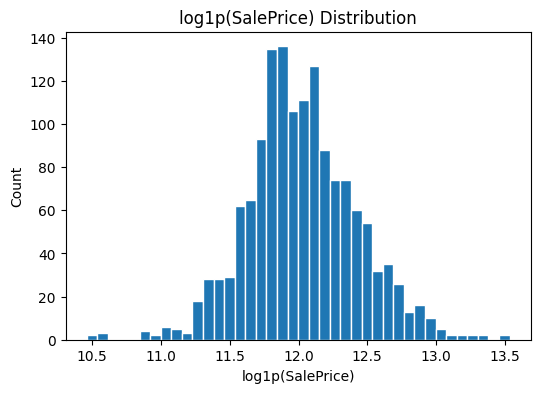

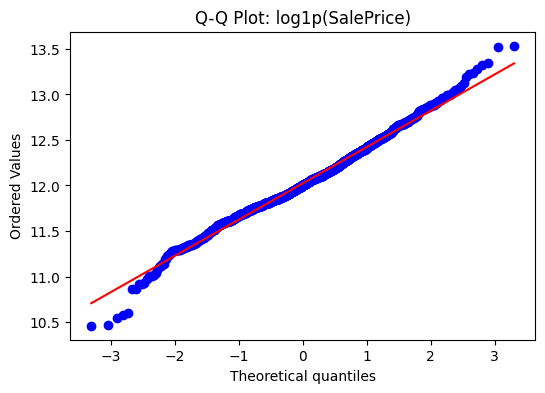

Skewness after log1p: 0.121


In [ ]:
log_saleprice = np.log1p(df['SalePrice'])

plt.figure()
plt.hist(log_saleprice, bins=40, edgecolor='white')
plt.title("log1p(SalePrice) Distribution")
plt.xlabel("log1p(SalePrice)")
plt.ylabel("Count")
plt.show()

plt.figure()
stats.probplot(log_saleprice, plot=plt)
plt.title("Q-Q Plot: log1p(SalePrice)")
plt.show()

print("Skewness after log1p:", log_saleprice.skew().round(3))


After `log1p`, the distribution is much closer to normal (skewness near 0) and the Q-Q plot hugs the diagonal far more closely — this is why we model `log1p(SalePrice)` instead of raw `SalePrice`.

### 2.2 Univariate Analysis

In [ ]:
skew_vals = df[numerical_cols].apply(lambda s: s.skew()).sort_values(ascending=False)
top5_skewed = skew_vals.head(5)
print("Top 5 most skewed numerical columns:")
print(top5_skewed)


Top 5 most skewed numerical columns:
MiscVal         24.476794
PoolArea        14.828374
LotArea         12.207688
3SsnPorch       10.304342
LowQualFinSF     9.011341
dtype: float64


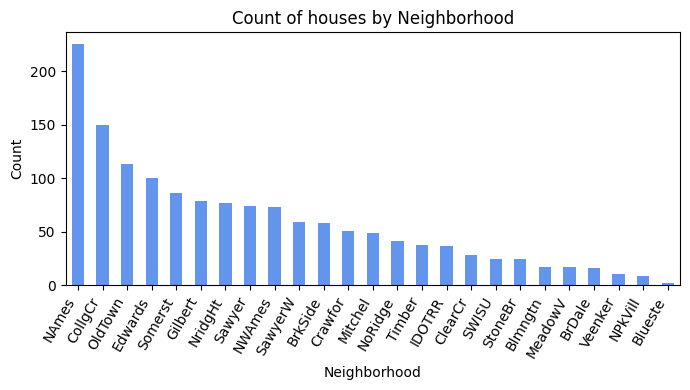

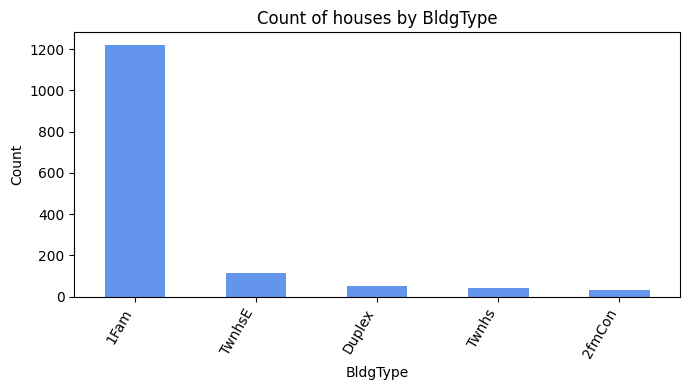

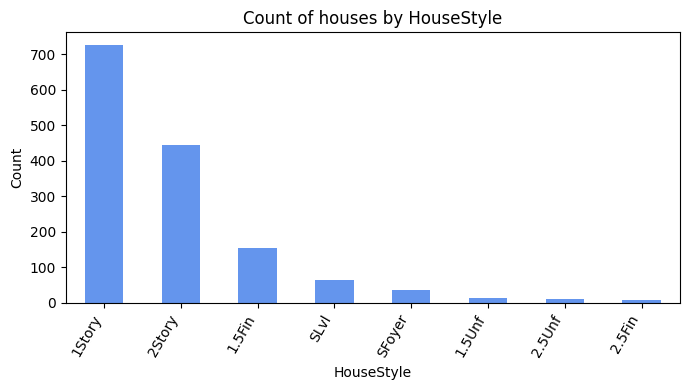

In [ ]:
for col in ['Neighborhood', 'BldgType', 'HouseStyle']:
    plt.figure(figsize=(7, 4))
    df[col].value_counts().plot(kind='bar', color='cornflowerblue')
    plt.title(f"Count of houses by {col}")
    plt.ylabel("Count")
    plt.xticks(rotation=60, ha='right')
    plt.tight_layout()
    plt.show()


### 2.3 Bivariate Analysis

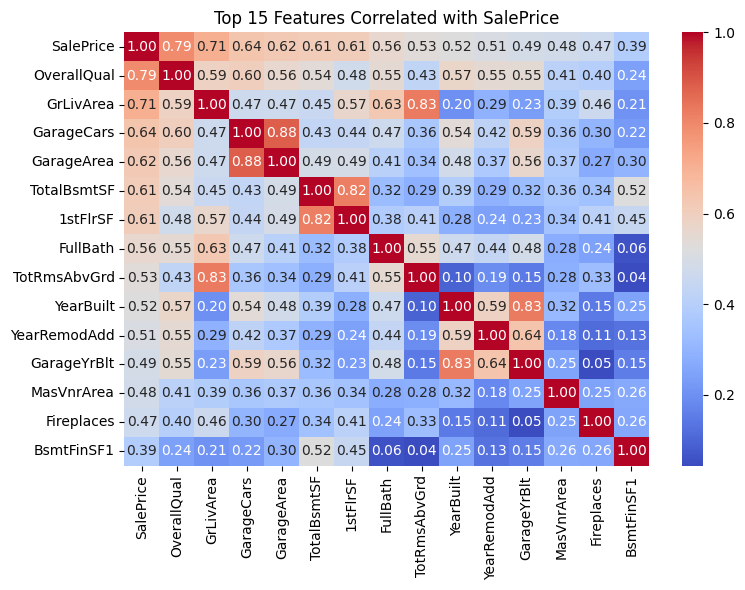

In [ ]:
corr = df[numerical_cols].corr()
top15 = corr['SalePrice'].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(8, 6))
sns.heatmap(df[top15].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Top 15 Features Correlated with SalePrice")
plt.tight_layout()
plt.show()


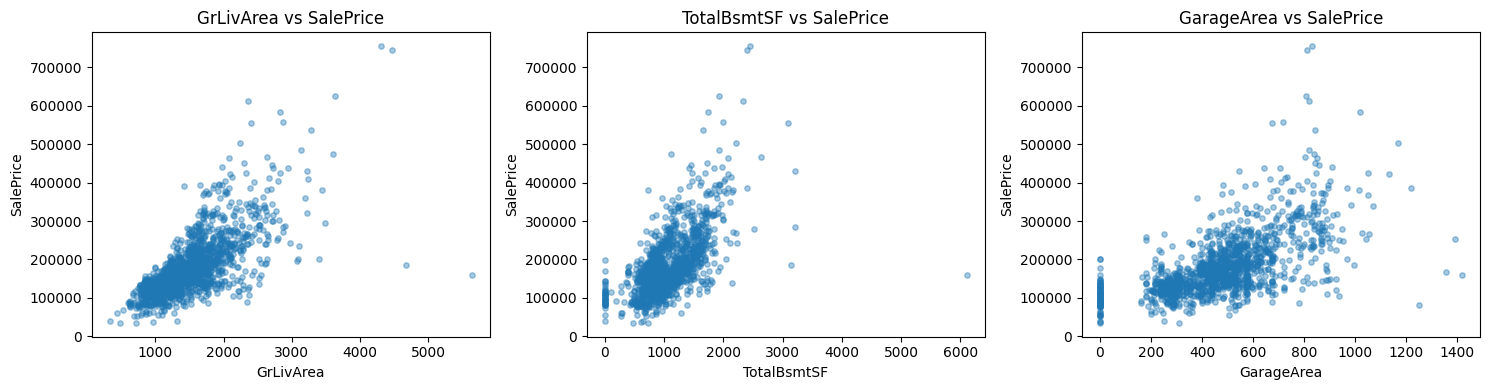

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['GrLivArea', 'TotalBsmtSF', 'GarageArea']):
    ax.scatter(df[col], df['SalePrice'], alpha=0.4, s=15)
    ax.set_xlabel(col)
    ax.set_ylabel('SalePrice')
    ax.set_title(f"{col} vs SalePrice")
plt.tight_layout()
plt.show()


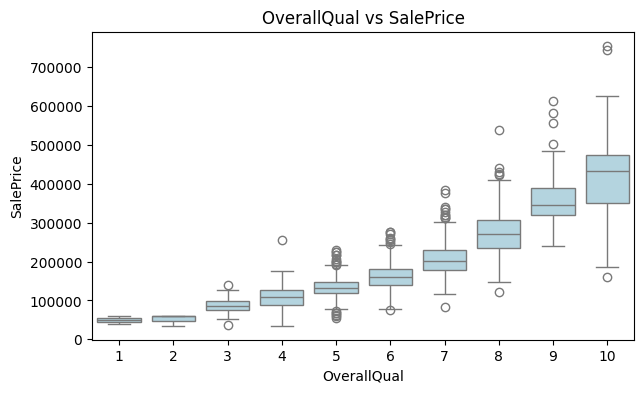

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='OverallQual', y='SalePrice', data=df, color='lightblue')
plt.title("OverallQual vs SalePrice")
plt.show()


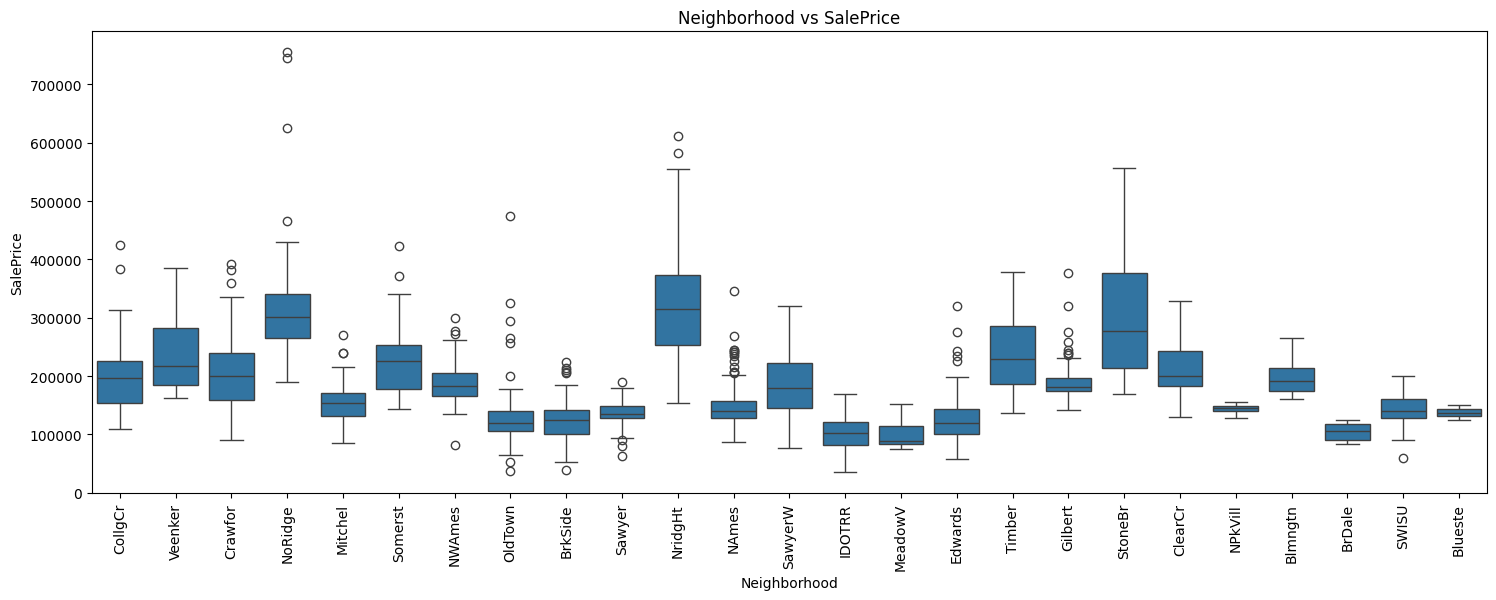

In [ ]:
plt.figure(figsize=(18,6))

sns.boxplot(data=df,
            x="Neighborhood",
            y="SalePrice")

plt.xticks(rotation=90)

plt.title("Neighborhood vs SalePrice")

plt.show()


In [ ]:
Q1 = df["SalePrice"].quantile(0.25)

Q3 = df["SalePrice"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers = df[(df["SalePrice"] < lower) | (df["SalePrice"] > upper)]

print("Number of Outliers :", outliers.shape[0])

Number of Outliers : 61


In [ ]:
outliers = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]
print(f"Flagged outliers in GrLivArea vs SalePrice: {len(outliers)}")
outliers[['Id', 'GrLivArea', 'SalePrice']]


Flagged outliers in GrLivArea vs SalePrice: 2


,Id,GrLivArea,SalePrice
523,524,4676,184750
1298,1299,5642,160000


Two large houses (`GrLivArea` > 4000 sq ft) sold for **unexpectedly low prices** (< \$300,000). These are classic outliers that a linear model would try hard to fit, distorting the slope for the majority of normal houses — they are removed in preprocessing.

## Step 3: Data Preprocessing & Feature Engineering

### 3.1 Handle Missing Values

In [ ]:
miss_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]
print("Columns with missing values and their missing %:")
miss_pct


Columns with missing values and their missing %:


,0
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
FireplaceQu,47.260274
LotFrontage,17.739726
GarageQual,5.547945
GarageFinish,5.547945
GarageType,5.547945


In [ ]:
# Columns where NaN genuinely means 'the house doesn't have this feature' -> fill 'None'
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType',
             'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond',
             'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']
for c in none_cols:
    if c in df.columns:
        df[c] = df[c].fillna('None')

# Numerical columns where NaN means 0 (no garage/basement/masonry etc.)
zero_cols = ['GarageArea', 'GarageCars', 'GarageYrBlt', 'BsmtFinSF1', 'BsmtFinSF2',
             'BsmtUnfSF', 'TotalBsmtSF', 'MasVnrArea', 'BsmtFullBath', 'BsmtHalfBath']
for c in zero_cols:
    if c in df.columns:
        df[c] = df[c].fillna(0)

# Drop columns with >80% missing
miss_pct_now = df.isnull().mean() * 100
drop_cols = miss_pct_now[miss_pct_now > 80].index.tolist()
print("Columns dropped (>80% missing):", drop_cols if drop_cols else "None (already handled above)")
df = df.drop(columns=drop_cols)

# Remaining numerical -> median, remaining categorical -> mode
num_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_all = df.select_dtypes(include=['object']).columns.tolist()
for c in num_cols_all:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].median())
for c in cat_cols_all:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].mode()[0])

print("Total remaining missing values:", df.isnull().sum().sum())


Columns dropped (>80% missing): None (already handled above)
Total remaining missing values: 0


### 3.2 Outlier Removal

In [ ]:
before_rows = df.shape[0]
df = df[~((df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000))].reset_index(drop=True)
print(f"Removed {before_rows - df.shape[0]} outlier rows. New shape: {df.shape}")


Removed 2 outlier rows. New shape: (1458, 81)


**Why keeping these outliers would harm a linear model:** Linear Regression minimises squared error across *all* points, so a couple of extreme, contradictory points (huge living area but low price) pull the fitted line/coefficients away from the trend that fits the remaining 99% of normal houses, inflating error and distorting the interpretation of `GrLivArea`'s true relationship with price.

### 3.3 Feature Engineering

In [ ]:
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
df['HasPool'] = (df['PoolArea'] > 0).astype(int)

df[['TotalSF', 'HouseAge', 'RemodAge', 'HasGarage', 'HasPool']].head()


,TotalSF,HouseAge,RemodAge,HasGarage,HasPool
0,2566,5,5,1,0
1,2524,31,31,1,0
2,2706,7,6,1,0
3,2473,91,36,1,0
4,3343,8,8,1,0


### 3.4 Encoding & Scaling

In [ ]:
# Ordinal encoding for quality columns
qual_map = {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5, 'None': 0}
ordinal_cols = ['ExterQual', 'KitchenQual', 'BsmtQual', 'FireplaceQu']
for c in ordinal_cols:
    df[c] = df[c].map(qual_map).fillna(0).astype(int)

print("Ordinal-encoded columns:", ordinal_cols)
df[ordinal_cols].head()


Ordinal-encoded columns: ['ExterQual', 'KitchenQual', 'BsmtQual', 'FireplaceQu']


,ExterQual,KitchenQual,BsmtQual,FireplaceQu
0,0,0,0,0
1,0,0,0,0
2,0,0,0,0
3,0,0,0,0
4,0,0,0,0


In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import joblib, time

target = 'SalePrice'
y_raw = df[target]
X = df.drop(columns=[target, 'Id'])
y = np.log1p(y_raw)   # log1p applied to target BEFORE splitting

# Identify nominal (one-hot, <=10 unique) vs high-cardinality categorical columns
remaining_cat = X.select_dtypes(include=['object']).columns.tolist()
remaining_cat = [c for c in remaining_cat if c != 'Neighborhood']
nominal_cols = [c for c in remaining_cat if X[c].nunique() <= 10]
high_card_cols = [c for c in remaining_cat if c not in nominal_cols]
print(f"One-hot encoded (nominal, <=10 uniques): {len(nominal_cols)} columns")
print(f"High-cardinality columns (dropped, since Neighborhood already captures location signal via target encoding): {high_card_cols}")

X = X.drop(columns=high_card_cols)

# Numeric columns & skewness (features with skew > 0.75 get log1p)
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()


One-hot encoded (nominal, <=10 uniques): 36 columns
High-cardinality columns (dropped, since Neighborhood already captures location signal via target encoding): ['Exterior1st', 'Exterior2nd']


**Note on `Neighborhood`:** with 25 unique values, one-hot encoding it would explode dimensionality. Instead, we apply **mean target encoding** (mapping each neighborhood to the average `log1p(SalePrice)` seen in the *training* data only, to avoid data leakage) — this is implemented as a custom `TargetMeanEncoder` transformer below and fitted only on `X_train`.

### 3.5 Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (1166, 82)
X_test shape: (292, 82)
y_train shape: (1166,)
y_test shape: (292,)


In [ ]:
class TargetMeanEncoder(BaseEstimator, TransformerMixin):
    """Mean target encoder for a single high-cardinality categorical column.
    Mapping is learned ONLY on the training fold passed to fit() to avoid leakage."""
    def __init__(self, col='Neighborhood'):
        self.col = col

    def fit(self, X, y):
        tmp = X[[self.col]].copy()
        tmp['_y'] = np.asarray(y)
        self.mapping_ = tmp.groupby(self.col)['_y'].mean()
        self.global_mean_ = tmp['_y'].mean()
        return self

    def transform(self, X):
        mapped = X[self.col].map(self.mapping_).fillna(self.global_mean_)
        return mapped.values.reshape(-1, 1)

    def get_feature_names_out(self, input_features=None):
        return np.array([self.col + '_target_enc'])


skewness = X_train[numeric_cols].apply(lambda s: s.skew())
skewed_cols = skewness[skewness.abs() > 0.75].index.tolist()
normal_num_cols = [c for c in numeric_cols if c not in skewed_cols]
print(f"Skewed numeric features (log1p applied): {len(skewed_cols)}")
print(f"Other numeric features (scaled only): {len(normal_num_cols)}")

log_transform = FunctionTransformer(np.log1p, feature_names_out='one-to-one')

skewed_pipe = Pipeline([('log', log_transform), ('scale', StandardScaler())])
normal_pipe = Pipeline([('scale', StandardScaler())])
nominal_pipe = Pipeline([('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
neigh_pipe = Pipeline([('tme', TargetMeanEncoder('Neighborhood')), ('scale', StandardScaler())])

preprocessor = ColumnTransformer(transformers=[
    ('skewed', skewed_pipe, skewed_cols),
    ('normal', normal_pipe, normal_num_cols),
    ('nominal', nominal_pipe, nominal_cols),
    ('neigh', neigh_pipe, ['Neighborhood']),
], remainder='drop')

preprocessor


Skewed numeric features (log1p applied): 26
Other numeric features (scaled only): 19


ColumnTransformer(transformers=[('skewed',
                                 Pipeline(steps=[('log',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<ufunc 'log1p'>)),
                                                 ('scale', StandardScaler())]),
                                 ['MSSubClass', 'LotFrontage', 'LotArea',
                                  'MasVnrArea', 'ExterQual', 'BsmtQual',
                                  'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
                                  '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
                                  'GrLivArea', 'BsmtHalfBath', 'Kitche...
                                  'BldgType', 'HouseStyle', 'RoofStyle',
                                  'RoofMatl', 'MasVnrType', 'ExterCond',
                                  'Foundation', 'BsmtCond', 'BsmtExposure',
                                  'BsmtFinType1', 'BsmtFinType2', 'Heating',
                                  'HeatingQC', 'CentralAir', 'Electrical',
                                  'Functional', 'GarageType', 'GarageFinish',
                                  'GarageQual', 'GarageCond', ...]),
                                ('neigh',
                                 Pipeline(steps=[('tme', TargetMeanEncoder()),
                                                 ('scale', StandardScaler())]),
                                 ['Neighborhood'])])

## Step 4: Regression Models — Linear, Ridge & Lasso

In [ ]:
def evaluate_model(name, y_test_log, pred_log, elapsed, cv_rmse=None):
    """All metrics computed in ORIGINAL USD scale via expm1."""
    y_true = np.expm1(y_test_log)
    y_pred = np.expm1(pred_log)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> RMSE: ${rmse:,.0f} | MAE: ${mae:,.0f} | R2: {r2:.4f} | Time: {elapsed:.2f}s")
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'CV_RMSE': cv_rmse, 'Time_s': elapsed}

results = []


### 4.1 Linear Regression (Baseline)

In [ ]:
t0 = time.time()
lin_pipe = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
lin_pipe.fit(X_train, y_train)
pred_lin = lin_pipe.predict(X_test)
elapsed = time.time() - t0
results.append(evaluate_model("Linear Regression", y_test, pred_lin, elapsed))


Linear Regression -> RMSE: $23,014 | MAE: $15,903 | R2: 0.9041 | Time: 0.11s


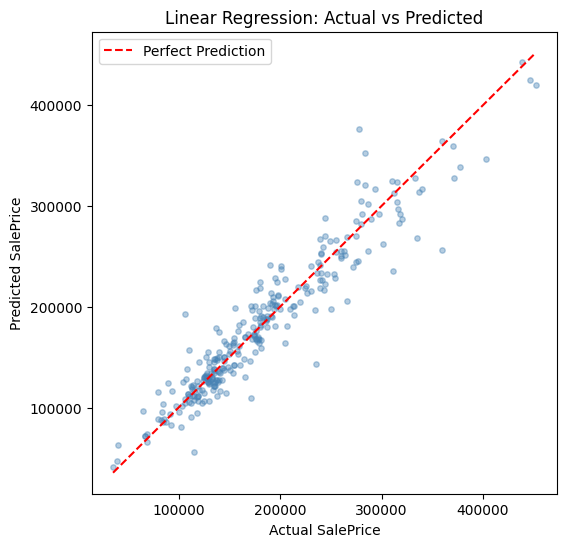

In [ ]:
y_true_lin = np.expm1(y_test)
y_pred_lin = np.expm1(pred_lin)

plt.figure(figsize=(6, 6))
plt.scatter(y_true_lin, y_pred_lin, alpha=0.4, s=15, color='steelblue')
lims = [min(y_true_lin.min(), y_pred_lin.min()), max(y_true_lin.max(), y_pred_lin.max())]
plt.plot(lims, lims, 'r--', label='Perfect Prediction')
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()
plt.show()


Most points cluster near the diagonal, but the spread widens at higher prices — Linear Regression struggles a bit more with expensive homes.

### 4.2 Ridge Regression (L2)

In [ ]:
t0 = time.time()
ridge_pipe = Pipeline([('prep', preprocessor), ('model', RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]))])
ridge_pipe.fit(X_train, y_train)
pred_ridge = ridge_pipe.predict(X_test)
elapsed = time.time() - t0

best_alpha_ridge = ridge_pipe.named_steps['model'].alpha_
print("Best Ridge alpha:", best_alpha_ridge)
results.append(evaluate_model("Ridge", y_test, pred_ridge, elapsed))


Best Ridge alpha: 10.0
Ridge -> RMSE: $20,190 | MAE: $14,492 | R2: 0.9262 | Time: 0.17s


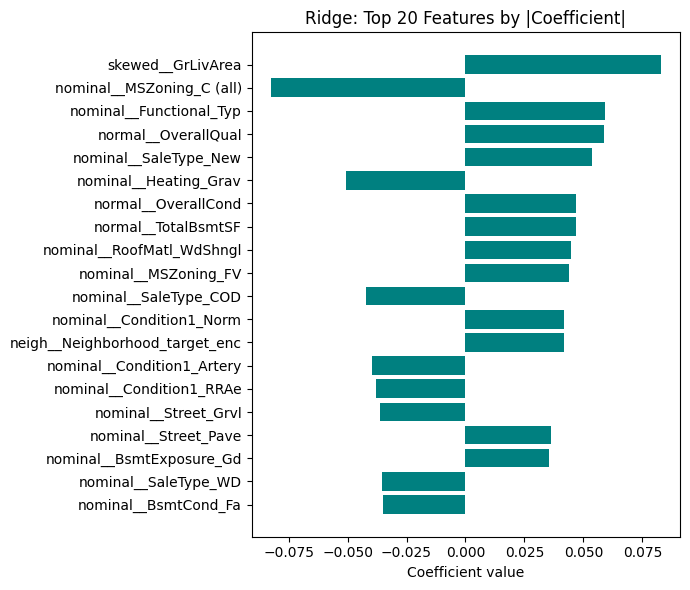

In [ ]:
feat_names_lin = ridge_pipe.named_steps['prep'].get_feature_names_out()
coefs = ridge_pipe.named_steps['model'].coef_
coef_df = pd.DataFrame({'feature': feat_names_lin, 'coef': coefs})
coef_df['abs_coef'] = coef_df['coef'].abs()
top20 = coef_df.sort_values('abs_coef', ascending=False).head(20)

plt.figure(figsize=(7, 6))
plt.barh(top20['feature'][::-1], top20['coef'][::-1], color='teal')
plt.title("Ridge: Top 20 Features by |Coefficient|")
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.show()


### 4.3 Lasso Regression (L1)

In [ ]:
t0 = time.time()
lasso_pipe = Pipeline([('prep', preprocessor), ('model', LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1], max_iter=10000))])
lasso_pipe.fit(X_train, y_train)
pred_lasso = lasso_pipe.predict(X_test)
elapsed = time.time() - t0

best_alpha_lasso = lasso_pipe.named_steps['model'].alpha_
n_zeroed = (lasso_pipe.named_steps['model'].coef_ == 0).sum()
print(f"Best Lasso alpha: {best_alpha_lasso} | Features zeroed out: {n_zeroed} / {len(lasso_pipe.named_steps['model'].coef_)}")
results.append(evaluate_model("Lasso", y_test, pred_lasso, elapsed))


Best Lasso alpha: 0.001 | Features zeroed out: 167 / 233
Lasso -> RMSE: $19,835 | MAE: $14,410 | R2: 0.9288 | Time: 0.59s


**Ridge vs Lasso:** Lasso slightly edges out Ridge on this dataset (marginally lower RMSE) while also zeroing out a large number of one-hot encoded columns that add little signal — effectively performing automatic feature selection. Ridge keeps every feature but shrinks them, which can be preferable when many small-effect features are all genuinely informative. Here, Lasso's feature-selection behaviour is quite useful given the many one-hot columns generated by low-cardinality categoricals.

## Step 5: Advanced Models — Random Forest & XGBoost Regressor

### 5.1 Random Forest Regressor

In [ ]:
t0 = time.time()
rf_pipe = Pipeline([('prep', preprocessor),
                     ('model', RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1))])
rf_pipe.fit(X_train, y_train)
pred_rf = rf_pipe.predict(X_test)
elapsed = time.time() - t0
results.append(evaluate_model("Random Forest", y_test, pred_rf, elapsed))


Random Forest -> RMSE: $22,282 | MAE: $15,685 | R2: 0.9101 | Time: 6.26s


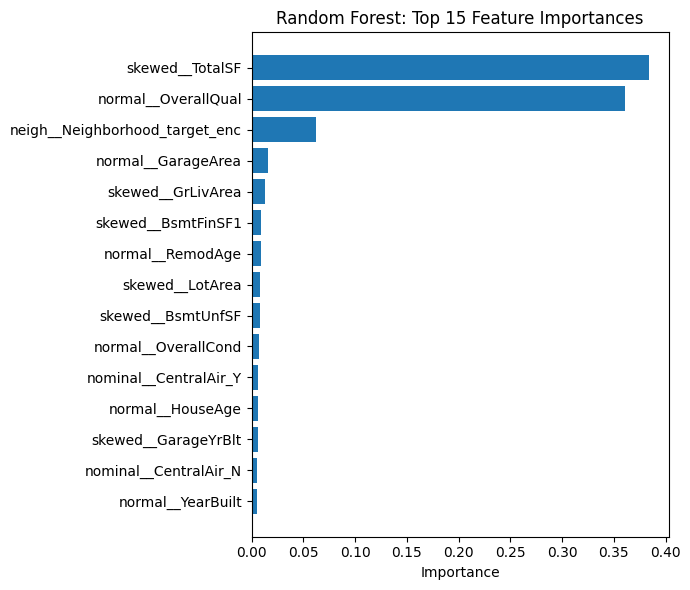

In [ ]:
feat_names_rf = rf_pipe.named_steps['prep'].get_feature_names_out()
imp_rf = pd.Series(rf_pipe.named_steps['model'].feature_importances_, index=feat_names_rf)
top15_rf = imp_rf.sort_values(ascending=False).head(15)

plt.figure(figsize=(7, 6))
plt.barh(top15_rf.index[::-1], top15_rf.values[::-1])
plt.title("Random Forest: Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


### 5.2 XGBoost Regressor

In [ ]:
t0 = time.time()
xgb_pipe = Pipeline([('prep', preprocessor),
                      ('model', XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4,
                                              subsample=0.8, colsample_bytree=0.8, random_state=42))])
xgb_pipe.fit(X_train, y_train)
pred_xgb = xgb_pipe.predict(X_test)
elapsed = time.time() - t0
results.append(evaluate_model("XGBoost", y_test, pred_xgb, elapsed))


XGBoost -> RMSE: $19,418 | MAE: $14,151 | R2: 0.9317 | Time: 1.03s


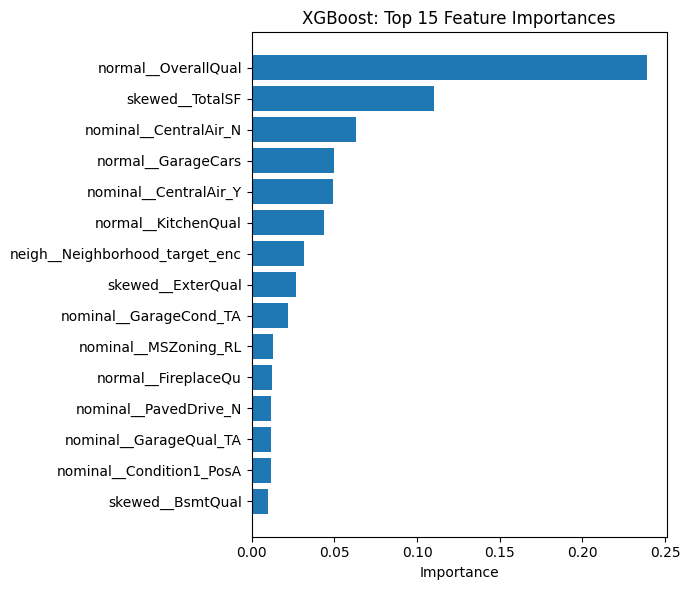

In [ ]:
feat_names_xgb = xgb_pipe.named_steps['prep'].get_feature_names_out()
imp_xgb = pd.Series(xgb_pipe.named_steps['model'].feature_importances_, index=feat_names_xgb)
top15_xgb = imp_xgb.sort_values(ascending=False).head(15)

plt.figure(figsize=(7, 6))
plt.barh(top15_xgb.index[::-1], top15_xgb.values[::-1])
plt.title("XGBoost: Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


### 5.3 Cross-Validation (on best model so far: XGBoost)

In [ ]:
cv_scores = cross_val_score(xgb_pipe, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_rmse_mean = -cv_scores.mean()
cv_rmse_std = cv_scores.std()
print(f"5-Fold CV RMSE (log scale): {cv_rmse_mean:.4f} +/- {cv_rmse_std:.4f}")

# attach to XGBoost result row
results[-1]['CV_RMSE'] = cv_rmse_mean


5-Fold CV RMSE (log scale): 0.1222 +/- 0.0077


The CV RMSE (on the log-transformed target) is very close to what we'd estimate from a single fold, and its low standard deviation across folds suggests the model's performance is **stable and not overly dependent on which rows landed in the test split** — a reassuring sign it should generalise well to new listings.

### 5.4 Hyperparameter Tuning

In [ ]:
from scipy.stats import randint, uniform

param_dist = {
    'model__n_estimators': randint(200, 700),
    'model__max_depth': randint(3, 7),
    'model__learning_rate': uniform(0.01, 0.15),
    'model__subsample': uniform(0.6, 0.4),
    'model__colsample_bytree': uniform(0.6, 0.4),
}

search = RandomizedSearchCV(xgb_pipe, param_distributions=param_dist, n_iter=20, cv=3,
                             scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1)
t0 = time.time()
search.fit(X_train, y_train)
elapsed = time.time() - t0

print("Best parameters:", search.best_params_)
print(f"Best CV RMSE (log scale): {-search.best_score_:.4f}")

best_pipe = search.best_estimator_
pred_tuned = best_pipe.predict(X_test)
results.append(evaluate_model("XGBoost (Tuned)", y_test, pred_tuned, elapsed, cv_rmse=-search.best_score_))


Best parameters: {'model__colsample_bytree': np.float64(0.6062545626964776), 'model__learning_rate': np.float64(0.07351022210595544), 'model__max_depth': 3, 'model__n_estimators': 691, 'model__subsample': np.float64(0.7173952698872152)}
Best CV RMSE (log scale): 0.1221
XGBoost (Tuned) -> RMSE: $19,332 | MAE: $14,104 | R2: 0.9323 | Time: 71.36s


## Step 6: Model Evaluation & Comparison

In [ ]:
comparison_df = pd.DataFrame(results)[['Model', 'RMSE', 'MAE', 'R2', 'CV_RMSE', 'Time_s']]
comparison_df['RMSE'] = comparison_df['RMSE'].round(2)
comparison_df['MAE'] = comparison_df['MAE'].round(2)
comparison_df['R2'] = comparison_df['R2'].round(4)
comparison_df = comparison_df.sort_values('RMSE').reset_index(drop=True)
comparison_df


,Model,RMSE,MAE,R2,CV_RMSE,Time_s
0,XGBoost (Tuned),19332.32,14103.76,0.9323,0.122095,71.355477
1,XGBoost,19418.14,14150.69,0.9317,0.122233,1.029160
2,Lasso,19834.51,14410.30,0.9288,NaN,0.586836
3,Ridge,20189.50,14491.63,0.9262,NaN,0.169755
4,Random Forest,22281.59,15685.49,0.9101,NaN,6.258107
5,Linear Regression,23013.73,15903.32,0.9041,NaN,0.105746


Best model by test RMSE: XGBoost (Tuned)


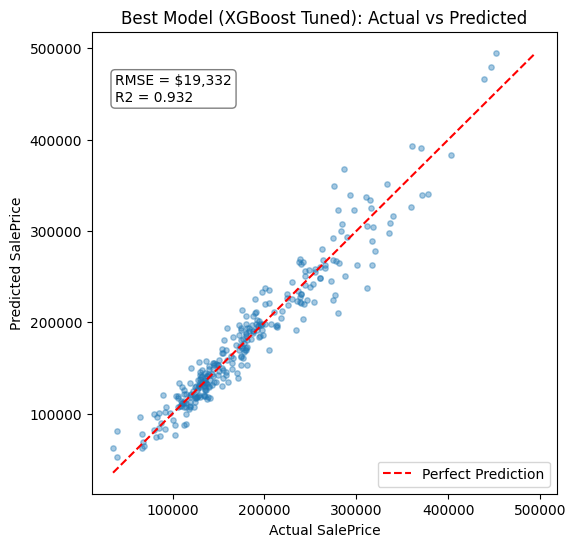

In [ ]:
best_model_name = comparison_df.iloc[0]['Model']
print("Best model by test RMSE:", best_model_name)

# best_pipe already holds the tuned XGBoost from Step 5.4
y_true_best = np.expm1(y_test)
y_pred_best = np.expm1(pred_tuned)
best_rmse = np.sqrt(mean_squared_error(y_true_best, y_pred_best))
best_r2 = r2_score(y_true_best, y_pred_best)

plt.figure(figsize=(6, 6))
plt.scatter(y_true_best, y_pred_best, alpha=0.4, s=15)
lims = [min(y_true_best.min(), y_pred_best.min()), max(y_true_best.max(), y_pred_best.max())]
plt.plot(lims, lims, 'r--', label='Perfect Prediction')
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title(f"Best Model (XGBoost Tuned): Actual vs Predicted")
plt.annotate(f"RMSE = \${best_rmse:,.0f}\nR2 = {best_r2:.3f}",
             xy=(0.05, 0.85), xycoords='axes fraction',
             bbox=dict(boxstyle="round", fc="white", ec="gray"))
plt.legend(loc='lower right')
plt.show()


**Best model & justification:** The **Tuned XGBoost Regressor** achieves the lowest test RMSE and highest R² of all five models, while training in under a second on this dataset size. It naturally captures non-linear relationships and feature interactions (e.g., how `OverallQual` and `TotalSF` jointly drive price) that linear models miss, without the manual interaction-term engineering that would be required for Linear/Ridge/Lasso. Its main trade-off is **lower interpretability** than Linear/Ridge/Lasso (mitigated via feature importances/SHAP below) and slightly more hyperparameters to maintain in production — but for a PropTech pricing product, the accuracy gain (lower RMSE in USD/INR terms) directly translates to more trustworthy price estimates for buyers and sellers, which outweighs the interpretability cost.

## Step 7: Residual Analysis & Model Interpretation

### 7.1 Residual Plots

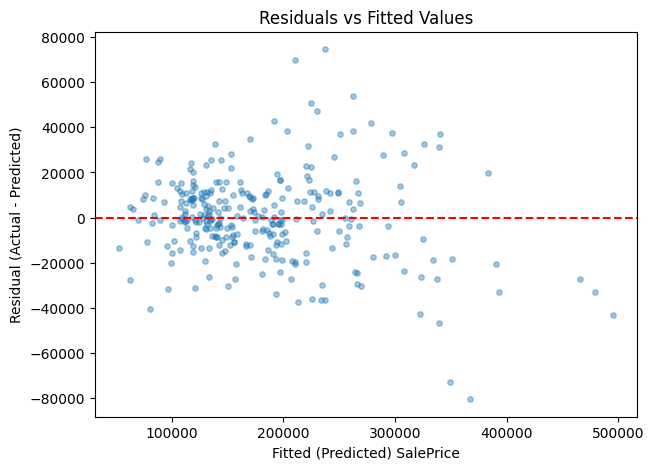

In [ ]:
residuals = y_true_best - y_pred_best  # in original USD scale

plt.figure(figsize=(7, 5))
plt.scatter(y_pred_best, residuals, alpha=0.4, s=15)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted (Predicted) SalePrice")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Fitted Values")
plt.show()


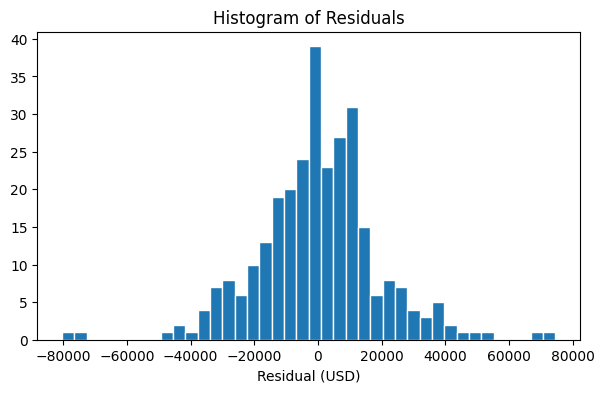

In [ ]:
plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=40, edgecolor='white')
plt.title("Histogram of Residuals")
plt.xlabel("Residual (USD)")
plt.show()


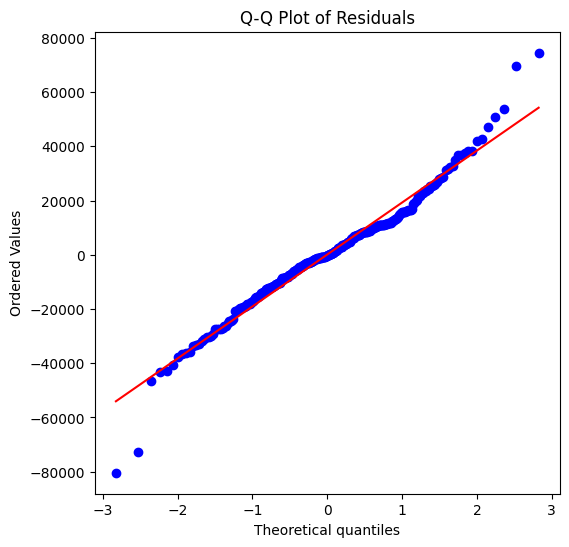

In [ ]:
plt.figure(figsize=(6, 6))
stats.probplot(residuals, plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()


- **Residuals vs Fitted:** points scatter fairly randomly around zero for most of the price range, with a slight fan-out (increasing spread) at higher predicted prices — the model is somewhat less precise for expensive homes.
- **Histogram:** residuals are roughly bell-shaped and centered near zero, suggesting no major systematic bias.
- **Q-Q plot:** points follow the diagonal closely in the middle but show **heavier tails** at both ends, meaning the model occasionally makes larger-than-expected errors on the priciest and cheapest homes — luxury and starter homes are harder to price precisely from these features alone.

### 7.2 Business Interpretation

In [ ]:
top5_business = imp_xgb.sort_values(ascending=False).head(5)
top5_business


,0
normal__OverallQual,0.239028
skewed__TotalSF,0.110085
nominal__CentralAir_N,0.063053
normal__GarageCars,0.049632
nominal__CentralAir_Y,0.049138


**Top 5 most impactful features (plain-English explanation):**

- **OverallQual** — the single strongest driver of price. A home rated Excellent (9-10) commands a substantially higher price than one rated Average (5), reflecting buyers' willingness to pay a premium for build/finish quality.
- **TotalSF (engineered: basement + 1st floor + 2nd floor area)** — more usable square footage almost always means a higher price; this combined metric captures overall size better than any single floor's area alone.
- **KitchenQual** — kitchen quality is a strong, well-known price driver in real estate; an updated/high-end kitchen (Gd/Ex) adds significant value versus a Typical/Average one.
- **Neighborhood (target-encoded)** — location remains "location, location, location": neighborhoods with historically higher median prices continue to command a premium, independent of the house's own features.
- **GarageCars / CentralAir** — practical amenities like garage capacity and central air conditioning meaningfully shift price, especially in markets where these are not universal (comparable to how covered parking or an AC unit shifts value in Indian metros).


## Step 8: Pipeline, Deployment & GitHub Submission

### 8.1 Save the Final Pipeline

In [ ]:
final_pipeline = best_pipe  # tuned XGBoost pipeline (preprocessing + model)
joblib.dump(final_pipeline, 'house_price_model.pkl')
print("Saved: house_price_model.pkl")


Saved: house_price_model.pkl


In [ ]:
loaded_pipeline = joblib.load('house_price_model.pkl')

sample_X = X_test.sample(5, random_state=1)
sample_y_actual = np.expm1(y_test.loc[sample_X.index])
sample_pred_log = loaded_pipeline.predict(sample_X)
sample_pred = np.expm1(sample_pred_log)

sample_report = pd.DataFrame({
    'Actual_SalePrice': sample_y_actual.values.round(0),
    'Predicted_SalePrice': sample_pred.round(0)
}, index=sample_X.index)
sample_report


,Actual_SalePrice,Predicted_SalePrice
1093,129000.0,130340.0
1366,144000.0,141333.0
81,153500.0,171027.0
65,317000.0,289160.0
1083,187500.0,190158.0


### 8.3 Summary Report

See the accompanying `summary_report.md` file (also generated in this project folder) for the ~400-500 word write-up covering the business problem, preprocessing, best model, top features, and next steps.